# Reviewing processes in Digital Humanities venues

The main goal of this activity is to identify the practice of reviewing processes established in some Digital Humanities (DH) venues, including conferences and journals. In particular, we want to check how many venues adopt open peer review processes instead of the classic ones that prescribe either the sole anonymity of reviewers (*single-blind* from now on) or the anonymity of both authors and reviewers (*double-blind* from now on).

Since the concept of open peer review can be decoupled along different dimensions depending on the possibilities a peer-reviewing process permits, we decided to adopt the taxonomy defined in the following article:

> Ross-Hellauer, T. (2017). What is open peer review? A systematic review. F1000Research, 6, 588. https://doi.org/10.12688/f1000research.11369.2

Such a taxonomy is composed of the following dimensions:
* open identities: authors and reviewers are aware of each other's identities;
* open reports: review reports are published alongside the relevant article;
* open participation: the wider community is able to contribute to the review process;
* open interaction: direct reciprocal discussion between author(s) and reviewers, and/or between reviewers, is allowed and encouraged;
* open pre-review manuscripts: manuscripts are made immediately available (e.g., via pre-print servers like arXiv) in advance of any formal peer review procedures;
* open final-version commenting: review or commenting on final "version of record" publications;
* open platforms ("decoupled review"): review is facilitated by a different organisational entity than the venue of publication.

This document introduces the workflow description (and, simultaneously, part of its execution) adopted for:
* gathering the necessary data from the Call for Papers of DH conferences and journals;
* processing the gathered information to analyse the current status of the reviewing processes in DH.

The workflow described in this document is semi-automatic. Some of the steps are fully automated using developed Python scripts. Other steps must be performed manually to complement and correct the results obtained via automatic procedures. It will be carefully described in the text, along with the various passages.

## Preliminaries

Before introducing the various steps of the workflow, it is important to create all the folders and variables necessary for the processing. First of all, there are the import statements used for enabling the reuse of specific Python modules.

In [105]:
from requests import get
from bs4 import BeautifulSoup
from pypdf import PdfReader
from os import makedirs
from os.path import exists, sep
from csv import DictReader, DictWriter
from glob import glob
from pandas import read_csv

The package `requests` is used for downloading material from the Web, while the packages `bs4` and `pypdf` are used to open in Python HTML and PDF documents, respectively, to simplify their processing. A few functions of the `os` package are also used to create the various folders where to store the data, while some functions and classes of `csv` and `pandas` are used to store, process, and visualise the data obtained.

The following code creates the basic folders used for storing the information about the Call for Papers of the DH venues, in PDF, HTML and TXT formats, depending on the source. In addition, it defines the path for two files, i.e. `cfp.csv` and `cfp_full.csv`, which contain the initial information about the DH venues to consider and the full detailed view of gathered data, respectively.

In [106]:
cfp_path = "cfp" + sep
html_path = cfp_path + "html" + sep
txt_path = cfp_path + "txt" + sep
pdf_path = cfp_path + "pdf" + sep
cfp_file = cfp_path + "cfp.csv"
cfp_full_file = cfp_path + "cfp_full.csv"

if not exists(txt_path):
    makedirs(txt_path)

if not exists(html_path):
    makedirs(html_path)

if not exists(pdf_path):
    makedirs(pdf_path)

## 1. Gathering DH venue basic information [manual step]

In this first step, we need to **create manually** the `cfp.csv` file in the path indicated in the preliminaries. The CSV file must have two columns named `name` and `cfp_url` containing the name of the venue and the URL referring to its webpage, where we can find information about its call for papers and, in particular, the reviewing process adopted.

For this run, we have gathered information about:
* the past five years of the annual conference organised by the [*Associazione per l'Informatica Umanistica ela Cultura Digitale (AIUCD)*](https://www.aiucd.it/);
* the past five years of the annual conference organised by the [*Alliance of Digital Humanities Organizations (ADHO)*](https://adho.org/);
* the [DH journals](https://dhjournals.github.io/list/) that are completely devoted to publishing DH articles, that are still active, have a URL associated, and specify a standard article submission procedure - more information about such a list can be found in:
  > Spinaci, G., Colavizza, G., & Peroni, S. (2022). A map of Digital Humanities research across bibliographic data sources. Digital Scholarship in the Humanities, 37(4), 1254–1268. https://doi.org/10.1093/llc/fqac016

## 2. Downloading information for preservation [computational step]

All the webpages indicated in the `cfp.csv` file are downloaded in the specified format (HTML or PDF), and a full textual version of their content is also retrieved and stored accordingly in the related folders specified in the preliminaries of this workflow.

The entire **step is performed automatically** by running the following Python code. It creates all related HTML, PDF and TXT files using the venue name from the `cfp.csv` file in lowercase and without spaces, and adds the appropriate extension according to the format. In addition, the script reports possible URLs that were not downloaded due to unpredictable network errors.

In [107]:
url_not_downloaded = []

with open(cfp_file) as f:
    csv = DictReader(f)
    for row in csv:
        name = row["name"].lower().replace(" ","")
        html_file = html_path + name + ".html"
        txt_file = txt_path + name + ".txt"
        pdf_file = pdf_path + name + ".pdf"

        if not ((exists(html_file) and exists(txt_file)) or 
                (exists(pdf_file) and exists(txt_file))):
            print("Downloading information for", name)
            try:
                res = get(row["cfp_url"])
                if res.status_code == 200:
                    if row["cfp_url"].endswith(".pdf"):
                        with open(pdf_path + name + ".pdf", "wb") as f:
                            f.write(res.content)

                        reader = PdfReader(pdf_path + name + ".pdf")
                        text = page.extract_text()
                        with open(txt_file, "w") as f:
                            f.write(text)
                    else:
                        with open(html_path + name + ".html", "wb") as f:
                            f.write(res.content)
                        
                        body = BeautifulSoup(res.text).find("body").get_text()
                        with open(txt_file, "w") as f:
                            f.write(body)
                        
                else:
                    print("Problems while downloading the webpage", row["cfp_url"],"- status code:", res.status_code)
                    url_not_downloaded.append((name, row["cfp_url"]))
            except Exception as e:
                print("Problems while downloading the webpage", row["cfp_url"],"- exception raised:", e)
                url_not_downloaded.append((name, row["cfp_url"]))
        else:
            print("Information for", name, "already present in the data")

print("\nMissing material:")
if url_not_downloaded:
    for name, url in url_not_downloaded:
        print(name, "-", url)
else:
    print("None.")

Information for dh2026 already present in the data
Information for dh2025 already present in the data
Information for dh2024 already present in the data
Information for dh2023 already present in the data
Information for dh2022 already present in the data
Information for aiucd2026 already present in the data
Information for aiucd2025 already present in the data
Information for aiucd2024 already present in the data
Information for aiucd2023 already present in the data
Information for aiucd2022 already present in the data
Information for computationalhumanitiesresearch already present in the data
Information for digitalhumanitiesquarterly already present in the data
Information for digitalscholarshipinthehumanities already present in the data
Information for digitalstudies already present in the data
Information for digitálisbölcsészet already present in the data
Information for internationaljournalofdigitalhumanities already present in the data
Information for internationaljournalofhuman

## 3. Fixing the missing material [semi-manual step]

If the last step returned that some of the URLs were not downloaded, they **should be downloaded manually** through a browser and stored in the appropriate directory depending on the format (HTML or PDF). The file name to use must be the venue name from the `cfp.csv` file in lowercase and without spaces, plus the appropriate extension (`.html` or `.pdf`) according to the format.

Once these manual additions are performed, the following Python script **should be executed**. It creates the appropriate textual version of the manually downloaded documents, adding them to the appropriate folder.

In [108]:
for html_file in glob(html_path + "*.html"):
    name = html_file.replace(html_path, "").replace(".html", "")
    txt_file = txt_path + name + ".txt"
    if not exists(txt_file):
        with open(html_file) as fp:
            body = BeautifulSoup(fp).find("body").get_text()
        with open(txt_file, "w") as f:
            print("Convert HTML to TXT for", name)
            f.write(body)

for pdf_file in glob(pdf_path + "*.pdf"):
    name = pdf_file.replace(pdf_path, "").replace(".pdf", "")
    txt_file = txt_path + name + ".txt"
    if not exists(txt_file):
        reader = PdfReader(pdf_file)
        text = ""
        for page in reader.pages:
            text += page.extract_text()
        with open(txt_file, "w") as f:
            print("Convert PDF to TXT for", name)
            f.write(text)

## 4. Creating the final data file [computational step]

A new file (`cfp_full.csv`) is created by extending the `cfp.csv` file with additional boolean information (initially set to `False`) to track the reviewing processes adopted by the various venues.

The entire **step is performed automatically** by running the following Python code. In particular, it adds the following fields:
* `single`: single-blind peer-review;
* `double`: double-blind peer-review;
* `identities`: open identities;
* `reports`: open reports;
* `participation`: open participation;
* `interaction`: open interaction;
* `prereview`: open pre-review manuscripts;
* `postpublication`: open final-version commenting;
* `platforms`: open platforms.

In [109]:
csv = []
existing = set()

if exists(cfp_full_file):
    with open(cfp_full_file) as f:
        for row in DictReader(f):
            existing.add(row["name"])
            csv.append(row)

with open(cfp_file) as f:
    for row in DictReader(f):
        if row["name"] not in existing:
            csv.append({
                "name": row["name"],
                "cfp_url": row["cfp_url"],
                "single": False,
                "double": False,
                "identities": False,
                "reports": False,
                "participation": False,
                "interaction": False,
                "prereview": False,
                "postpublication": False,
                "platforms": False
        })

with open(cfp_full_file, "w", encoding="utf-8") as g:
    writer = DictWriter(g, ["name", "cfp_url", "single", "double", "identities", "reports", 
                            "participation", "interaction", "prereview", 
                            "postpublication", "platforms"])
    writer.writeheader()
    writer.writerows(csv)

## 5. Update the full table of information [manual step]

Each row of the table in `cfp_full.csv` should be modified depending on the specific reviewing process that is adopted by the various venues listed. In particular, for each venue, we **manually open the related URL** in a browser, read the webpage, and set to `True` the related fields of the `cfp_full.csv` file when they apply. For the open peer review processes, it is possible to set more than one field per venue to `True` if multiple dimensions are actually defined in the related URL.

We set all the reviewing fields to `False` in case it is not clear which kind of review process a particular venue uses.

## 6. Visualising the results [computational step]

The updated `cfp_full.csv` file is then read to create a visualisation of the results. The entire **step is performed automatically** by running the following Python code. It produces a horizontal bar chart with the number of times (x-axis) the specified review dimension has been mentioned (y-axis). Only terms that have been matched at least once are included in the diagram.

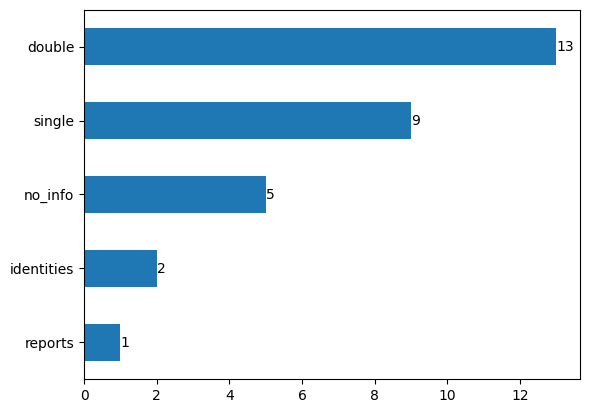

In [111]:
df = read_csv(cfp_full_file, keep_default_na=False)
count = df.drop(["name", "cfp_url"], axis=1).isin([True]).sum(axis=0)

no_info = len(df.query("single == False and double == False and identities == False and reports == False and participation == False and interaction == False and prereview == False and postpublication == False and platforms == False"))
count["no_info"] = no_info

count = count[count > 0].sort_values()
ax = count.plot(kind="barh")

for container in ax.containers:
    ax.bar_label(container)